# Projeto de K Means Clustering  


Para este projeto, tentaremos usar o KMeans Clustering para agrupar Universidades em dois grupos: Privadas e Públicas.


___
É muito importante observar, nós realmente temos os rótulos para este conjunto de dados, mas NÃO os usaremos para o algoritmo de agrupamento KMeans, pois esse é um algoritmo de aprendizado não supervisionado. **

Ao usar o algoritmo Kmeans em situações reais, você não possuirá rótulos. Nesse caso, usaremos os rótulos para tentar ter uma idéia do quão bem o algoritmo foi executado, apenas.
___

## Os dados

Usaremos um quadro de dados com 777 observações sobre as 18 variáveis a seguir.
* Private: Um fator com níveis Não e Sim, indicando universidade privada ou pública.
* Apps: Número de inscrições recebidas.
* Accept: Quantidade de inscrições aceitas.
* Enroll: Número de estudantes matriculados.
* Top10perc: Percentual de novos estudantes vindo do grupo de 10% melhores do segundo grau.
* Top25perc: Percentual de novos estudantes vindo do grupo de 25% melhores do segundo grau.
* F.Undergrad: Número de alunos de graduação em tempo integral.
* P.Undergrad Número de alunos de graduação em tempo parcial.
* Outstate: Aulas fora do estado.
* Room.Board: Custos da sala.
* Books: Custos de livros estimados.
* Personal: Estimativa de gastos por pessoa.
* PhD: Percentual de PHD's na universidade.
* Terminal: Percentual da faculdade com graduação.
* S.F.Ratio: Taxa estudantes/faculdade.
* perc.alumni: Percentual dos ex-alunos que doam.
* Expend: Despesas da instituição por aluno.
* Grad.Rate: Taxa de graduação

## Importar bibliotecas

** Importe as bibliotecas que você costuma usar para análise de dados. **

In [3]:
# Pandas: usada para leitura, limpeza, manipulação e análise de dados em formato de tabela
# (CSV, Excel, DataFrame, Series, etc.)
import pandas as pd

# NumPy: base matemática do Python científico
# Usada para vetores, matrizes, álgebra linear, estatística e operações numéricas rápidas
import numpy as np

# Matplotlib (pyplot): biblioteca base para criação de gráficos
# Dá controle total sobre eixos, títulos, escalas e elementos visuais
import matplotlib.pyplot as plt

# Seaborn: biblioteca de visualização estatística de alto nível
# Construída sobre o Matplotlib, facilita gráficos bonitos e integrados com pandas
import seaborn as sns

# pandas → organizar e preparar dados
# numpy → fazer contas e matemática pesada
# matplotlib → desenhar gráficos com controle fino
# seaborn → explorar dados visualmente com menos código


## Obtenha os dados
** Leia no arquivo College_Data usando read_csv. Descubra como setar a primeira coluna como índice. **

In [5]:
df = pd.read_csv('College_Data', index_col=0)

In [6]:
# ver os dados
df

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


In [7]:
# ** Verifique o cabeçalho dos dados **
df.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [9]:
# ** Verifique os métodos info() e describe() do DataFrame. **
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 777 entries, Abilene Christian University to York College of Pennsylvania
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Private      777 non-null    object 
 1   Apps         777 non-null    int64  
 2   Accept       777 non-null    int64  
 3   Enroll       777 non-null    int64  
 4   Top10perc    777 non-null    int64  
 5   Top25perc    777 non-null    int64  
 6   F.Undergrad  777 non-null    int64  
 7   P.Undergrad  777 non-null    int64  
 8   Outstate     777 non-null    int64  
 9   Room.Board   777 non-null    int64  
 10  Books        777 non-null    int64  
 11  Personal     777 non-null    int64  
 12  PhD          777 non-null    int64  
 13  Terminal     777 non-null    int64  
 14  S.F.Ratio    777 non-null    float64
 15  perc.alumni  777 non-null    int64  
 16  Expend       777 non-null    int64  
 17  Grad.Rate    777 non-null    int64  
dtypes: 

In [10]:
# ver o formato dos dados
df.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


## Análise exploratória de dados

É hora de criar algumas visualizações de dados.

** Crie um scatterplot de Grad.Rate versus Room.Board onde os pontos são coloridos pela coluna "Private". **

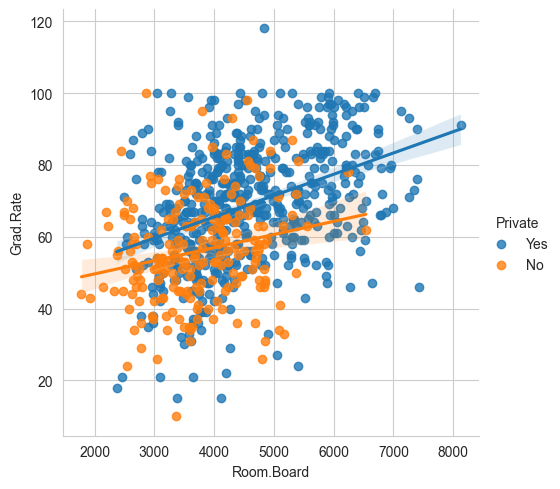

In [15]:
sns.lmplot(x='Room.Board', y='Grad.Rate', data=df, hue='Private')

# resposta que o pessoal que cursa faculdade eh a faculdade private 

** Crie um scatterplot de F.Undergrad versus Outstate onde os pontos são coloridos pela coluna Private.

F.Undergrad: Número de alunos de graduação em tempo integral.
Outstate: Aulas fora do estado.


**

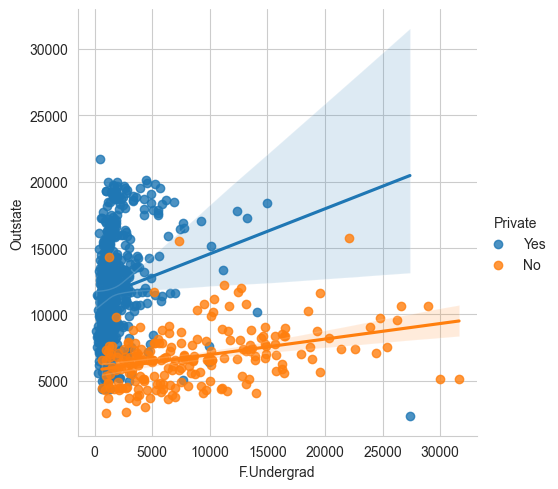

In [21]:
# sns.lmplot('F.Undergrad', 'Outstate', data=df, hue='Private')

sns.lmplot(
    x='F.Undergrad',
    y='Outstate',
    data=df,
    hue='Private'
)


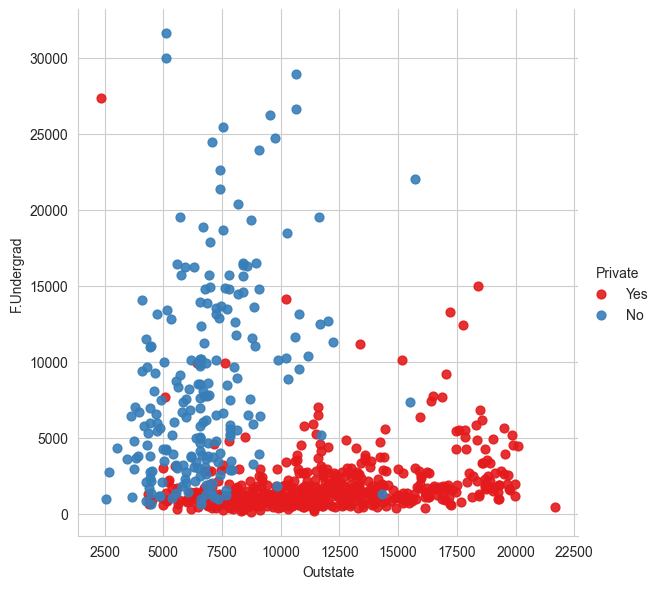

In [22]:
sns.lmplot(
    x='Outstate',
    y='F.Undergrad',
    data=df,
    hue='Private',
    fit_reg=False,
    height=6,
    palette='Set1',
    scatter_kws={'alpha': 0.9, 's': 40}
)



** Crie um histograma empilhado que mostra o "Out of State Tuition" com base na coluna Private. Tente fazer isso usando [sns.FacetGrid](https://stanford.edu/~mwaskom/software/seaborn/generated/seaborn.FacetGrid.html). Se isso for muito complicado, veja se você pode fazê-lo apenas usando duas instâncias de pandas.plot(kind='hist'). **

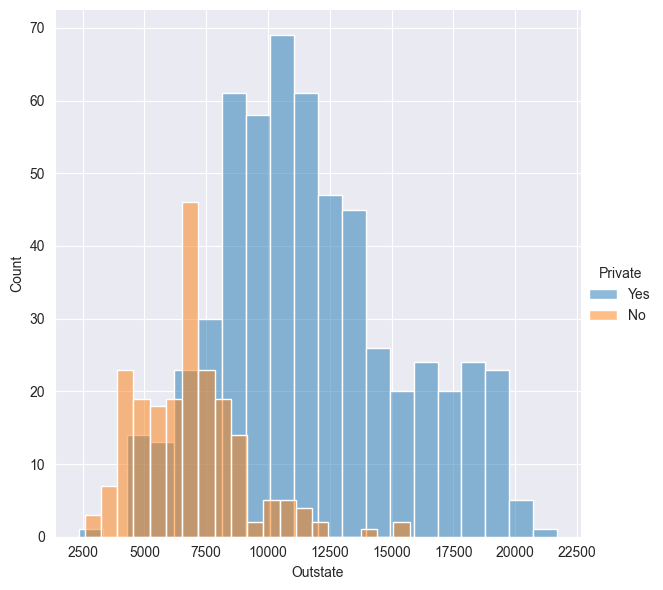

In [24]:
sns.set_style('darkgrid')

g = sns.FacetGrid(df, hue='Private', height=6)
g.map(sns.histplot, 'Outstate', bins=20, alpha=0.5)
g.add_legend()


<Axes: ylabel='Frequency'>

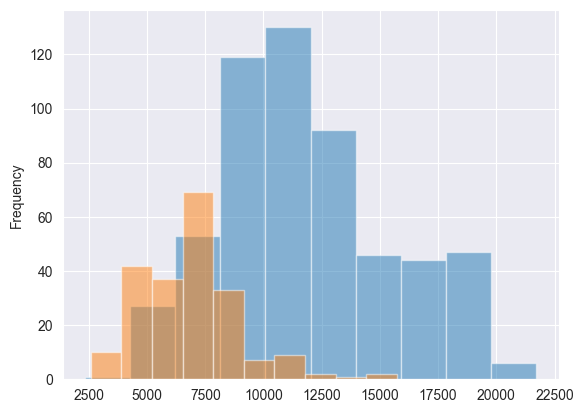

In [26]:
df[df['Private'] == 'Yes']['Outstate'].plot(kind='hist', alpha=0.5)
df[df['Private'] == 'No']['Outstate'].plot(kind='hist', alpha=0.5)

In [ ]:
df[df['Private'] == 'Yes']['Outstate'].plot(kind='hist', alpha=0.5)
df[df['Private'] == 'No']['Outstate'].plot(kind='hist', alpha=0.5)

** Crie um histograma semelhante para a coluna Grad.Rate. **

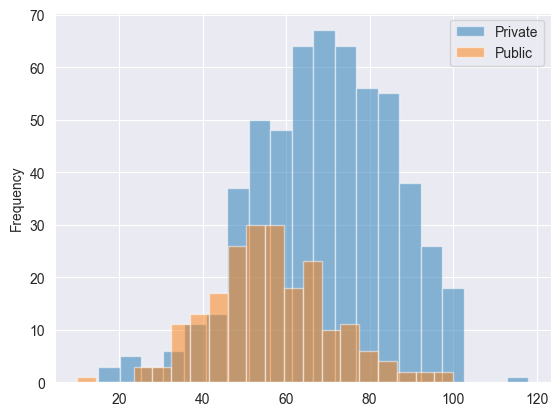

In [29]:
bins = 20

df[df['Private'] == 'Yes']['Grad.Rate'].plot(
    kind='hist',
    bins=bins,
    alpha=0.5,
    label='Private'
)

df[df['Private'] == 'No']['Grad.Rate'].plot(
    kind='hist',
    bins=bins,
    alpha=0.5,
    label='Public'
)

plt.legend()


In [30]:
# coclui que a uma taxa de conclusao mais na faculdade privada que na publica